In [2]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Abrimos el archivo
def load_vars(filename):
    file = uproot.open(filename)
    tree = file["T"]

    xptar = tree["P.gtr.th"].array(library="np")
    yptar = tree["P.gtr.ph"].array(library="np")

    etot = tree["P.cal.etottracknorm"].array(library="np")
    delta = tree["P.gtr.dp"].array(library="np")
    z = tree["P.react.z"].array(library="np")

    cut = (
    (etot > 0.8) &
    (np.abs(delta - 5) < 15) &
    (np.abs(z) < 1)
    )

    return xptar[cut], yptar[cut]

bins = [150, 150]
ranges = [[-0.06, 0.06], [-0.06, 0.06]]





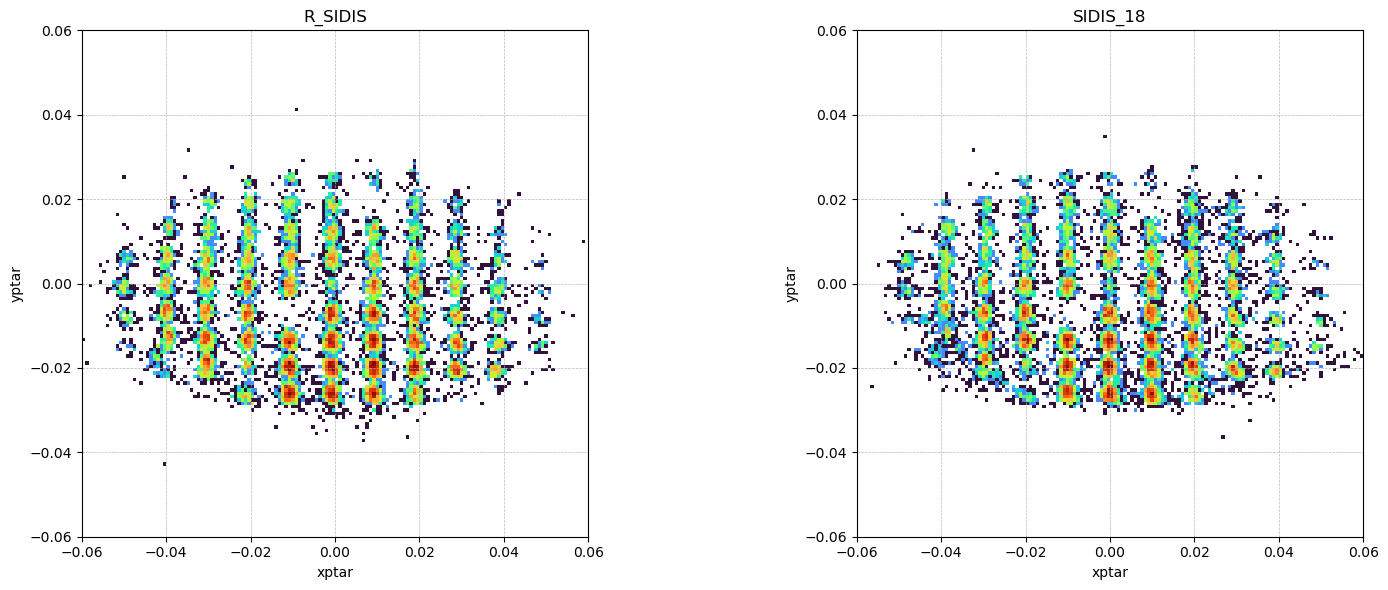

In [3]:
x_r, y_r = load_vars("optics_rsidis/shms_coin_replay_production_25521_-1.root")
x_18, y_18 = load_vars("optics_sidis18/coin_replay_production_5335_-1.root")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R_SIDIS
h1 = axes[0].hist2d(
    x_r, y_r,
    bins=bins,
    range=ranges,
    cmap="turbo",
    norm=colors.LogNorm()  # optional: ROOT defaults are log-like
)
axes[0].set_title("R_SIDIS")
axes[0].set_xlabel("xptar")
axes[0].set_ylabel("yptar")
axes[0].set_aspect('equal', adjustable='box')
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.9)
# fig.colorbar(h1[3], ax=axes[0], label="Counts")

# SIDIS_18 
h2 = axes[1].hist2d(
    x_18, y_18,
    bins=bins,
    range=ranges,
    cmap="turbo",
    norm=colors.LogNorm()
)
axes[1].set_title("SIDIS_18")
axes[1].set_xlabel("xptar")
axes[1].set_ylabel("yptar")
axes[1].set_aspect('equal', adjustable='box')
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.9)
# fig.colorbar(h2[3], ax=axes[1], label="Counts")

plt.tight_layout()
plt.show()

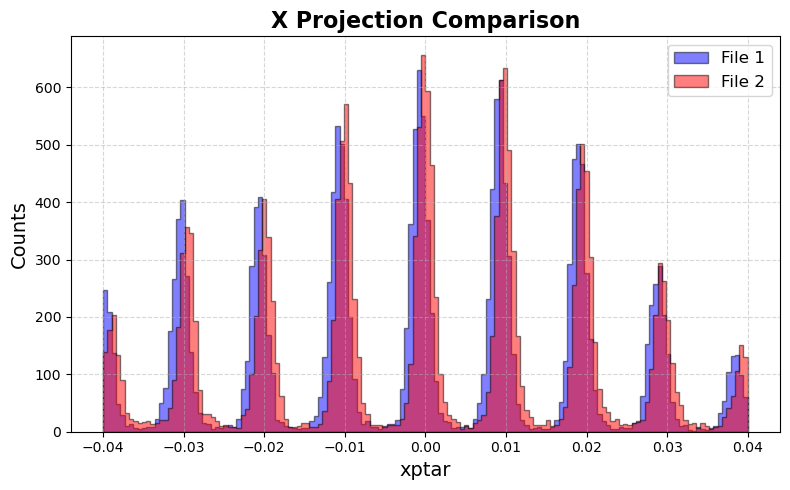

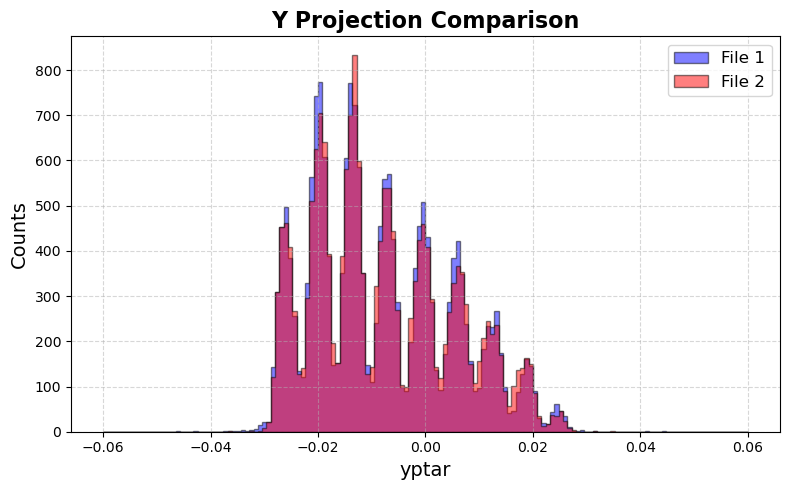

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Same bins & ranges as 2D histogram
# -----------------------
xbins = np.linspace(-0.04, 0.04, 151)   # 150 bins
ybins = np.linspace(-0.06, 0.06, 151)   # 150 bins

# -----------------------
# Plot X projections overlayed (filled histograms)
# -----------------------
plt.figure(figsize=(8,5))
plt.hist(x_r, bins=xbins, histtype='stepfilled', alpha=0.5, label="File 1", color='blue', edgecolor='black')
plt.hist(x_18, bins=xbins, histtype='stepfilled', alpha=0.5, label="File 2", color='red', edgecolor='black')

plt.title("X Projection Comparison", fontsize=16, fontweight="bold")
plt.xlabel("xptar", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# -----------------------
# Plot Y projections overlayed (filled histograms)
# -----------------------
plt.figure(figsize=(8,5))
plt.hist(y_r, bins=ybins, histtype='stepfilled', alpha=0.5, label="File 1", color='blue', edgecolor='black')
plt.hist(y_18, bins=ybins, histtype='stepfilled', alpha=0.5, label="File 2", color='red', edgecolor='black')

plt.title("Y Projection Comparison", fontsize=16, fontweight="bold")
plt.xlabel("yptar", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

